<a href="https://colab.research.google.com/github/zeqkik/mdc_lambda_projeto_final/blob/main/05_efficientnetv2b0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
from datetime import datetime
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, roc_curve, auc
from types import NoneType
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Input
from sklearn.model_selection import StratifiedKFold

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Funções Úteis

In [4]:
def predict_and_evaluate(model, features, labels, threeshold = 0.5):

  pred_proba = model.predict(features)
  pred_positive = pred_proba[:, 1]
  pred = np.where(pred_positive > threeshold, 1, 0)
  if type(labels) != NoneType:
    bal_acc = balanced_accuracy_score(labels, pred)

    print('=='*10)
    print(f'Balanced Accuracy: {bal_acc}')
    print('=='*10)

    report = classification_report(labels, pred, zero_division=0)
    print(report)
    plot_confusion_matrix(labels, pred, ['benigna', 'maligna'], 2)


    return pred_proba, pred, bal_acc, report
  else:
    return pred_proba, pred

In [5]:
def plot_roc_curve(true: np.ndarray, pred: np.ndarray):
    prob_positive = pred[:, 1]

    fpr, tpr, thresholds = roc_curve(true, prob_positive)
    roc_auc = auc(fpr, tpr)

    j_scores = tpr - fpr
    j_index = np.argmax(j_scores)

    optimal_threshold = thresholds[j_index]
    plt.figure(figsize=(8, 6))

    # Curva do Modelo
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Curva ROC (AUC = {roc_auc:.4f})')

    # Linha de classificação aleatória
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')

    # Ponto do threshold ideal
    plt.plot(fpr[j_index], tpr[j_index], 'ro', markersize=8,
             label=f'Threshold Ideal ({optimal_threshold:.4f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
    plt.title('Curva ROC e Threshold Ótimo para Classificador de Melanoma')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return optimal_threshold, roc_auc

In [6]:
IMAGE_SIZE = (224, 224)

def load_and_preprocess(file_path, label):
    """
    Função para carregar a aplicar pré processamento básico em uma imagem.
    Transformação da imagem em tensor e redimensionamento.
    """
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)

    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.efficientnet.preprocess_input(image)

    return image, label

In [7]:
def load_and_preprocess_test(file_path):
    """
    Função para carregar a aplicar pré processamento básico em uma imagem.
    Transformação da imagem em tensor e redimensionamento.
    """
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)

    image = tf.cast(image, tf.float32)
    # Normalização específica do EfficientNet
    image = tf.keras.applications.efficientnet.preprocess_input(image)

    return image

In [ ]:

def augment_data(image, label):
    """
    Função que aplica transformações aleatórias (Data Augmentation) na imagem.
    """
    # Flips esquerda direita, cima baixo
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)

    # Rotações de 90º
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)

    # Redimensionamento(Zoom-in 256x256 + Corte aleatório)
    image = tf.image.resize(image, [256, 256]) # Um leve zoom in
    image = tf.image.random_crop(image, size=[224, 224, 3])


    # Transformações de Cor
    image = tf.image.random_brightness(image, max_delta=0.1) # +/- 10%
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2) # +/- 20%
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2) # Saturação da cor

    # Manutenção de valores em limite válido
    image = tf.clip_by_value(image, 0.0, 255.0)

    return image, label


In [8]:
BATCH_SIZE = 128
BASE_DIR = '/content/drive/MyDrive/MDC_data/images/'

## Carregamento e Pré-processamento do Dataset

In [ ]:
# Carregamento o dataframe de rótulos e criação do conjunto de dados como
# Dataset para obter performance otimizada de processamento

train_info = pd.read_csv("/content/drive/MyDrive/MDC_data/train.csv")

train_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in train_info['path']]

y_train = train_info['target'].values

train_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(train_file_paths), tf.constant(y_train)))

train_images_ds = train_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)

train_ds_augmented = train_images_ds.shuffle(buffer_size=1024).map(
                    augment_data, # <--- Usando a nova função completa
                    num_parallel_calls=tf.data.AUTOTUNE
)

train_batches = train_ds_augmented.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [ ]:
val_info = pd.read_csv("/content/drive/MyDrive/MDC_data/val.csv")

val_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in val_info['path']]

y_val = val_info['target'].values

val_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(val_file_paths), tf.constant(y_val)))
val_images_ds = val_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)

val_batches = val_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [10]:
def plot_confusion_matrix(y_true, y_pred, class_names, NUM_CLASSES=4):
  cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))).astype("float")
  cm = cm / cm.sum(axis=1, keepdims=True)

  plt.figure(figsize=(6,5))
  sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=True,
        linewidths=.5,
        linecolor='black'
    )

  plt.title("Matriz de Confusão Normalizada")
  ticks = np.arange(NUM_CLASSES)
  plt.xticks(ticks + 0.5, class_names, rotation=45, ha="right")
  plt.yticks(ticks + 0.5, class_names, rotation=0)
  plt.ylabel("Verdadeiro")
  plt.xlabel("Predito")
  plt.tight_layout()
  plt.show()

In [11]:
classes = np.unique(y_train)


weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

## Avaliação do Tranfer Learning com o modelo EfficientNetV2B0

In [ ]:
base_model = tf.keras.applications.EfficientNetV2B0(weights ='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. CONGELAR completamente a base (Feature Extraction puro)
base_model.trainable = False

# Congelamento de todas camadas
#for layer in model.layers:
#    layer.trainable = False
# #Congelamento de n camadas
#for layer in base_model.layers[:-40]:
#    layer.trainable = False

model = tf.keras.Sequential([base_model,
                              tf.keras.layers.GlobalAveragePooling2D(),
                              Dropout(rate=0.3),
                              Dense(2, activation = 'softmax')])

input_shape = (None, 224, 224, 3)
model.build(input_shape=input_shape)
model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,921,874 (22.59 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
#SGD
sgd = tf.keras.optimizers.SGD(learning_rate = 0.001, momentum = 0.9, decay = 0.001)

#Adam
learning_rate = 1e-3 # Uso de baixa taxa de aprendizado
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

#Early stopping
early = tf.keras.callbacks.EarlyStopping (monitor = 'val_loss', patience = 5, restore_best_weights = True)
f1_score = keras.metrics.F1Score(average = 'macro')

# Compila o modelo (assumindo que 'frozen_model' está definido).
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = optimizer, metrics=['accuracy'])


In [ ]:
# Treinamento da Head
n_epochs = 10
history_a = model.fit(train_batches,
          epochs = n_epochs,
          class_weight = class_weights,
          validation_data = val_batches,
          callbacks=[early])


Epoch 1/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 141s 140ms/step - accuracy: 0.8650 - loss: 0.3091 - val_accuracy: 0.8144 - val_loss: 0.4352
Epoch 2/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8827 - loss: 0.2662 - val_accuracy: 0.8388 - val_loss: 0.4144
Epoch 3/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - accuracy: 0.9031 - loss: 0.2357 - val_accuracy: 0.8696 - val_loss: 0.3390
Epoch 4/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - accuracy: 0.9130 - loss: 0.2146 - val_accuracy: 0.8544 - val_loss: 0.4246
Epoch 5/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9281 - loss: 0.1774 - val_accuracy: 0.8736 - val_loss: 0.4169
Epoch 6/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9373 - loss: 0.1599 - val_accuracy: 0.8576 - val_loss: 0.4123
Epoch 7/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9386 - loss: 0.1515 - val_accuracy: 0.8792 - val_loss: 0.3891
Epoch 8/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9431 - loss: 0.1404 

In [ ]:
# Treinamento de Backbone - Fine tuning completo

base_model.trainable = True

#Adam
learning_rate = 1e-4 # Uso de baixa taxa de aprendizado
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

#Early stopping
early = tf.keras.callbacks.EarlyStopping (monitor = 'val_loss', patience = 5, restore_best_weights = True)
f1_score = keras.metrics.F1Score(average = 'macro')

# Compila o modelo (assumindo que 'frozen_model' está definido).
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = optimizer, metrics=['accuracy'])


In [ ]:
# Treinamento
history_b = model.fit(
    train_batches,
    class_weight = class_weights,
    epochs=40,
    validation_data=val_batches,
    callbacks=[early]
)

Epoch 1/40
636/636 ━━━━━━━━━━━━━━━━━━━━ 140s 141ms/step - accuracy: 0.9297 - loss: 0.1749 - val_accuracy: 0.8836 - val_loss: 0.3178
Epoch 2/40
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9490 - loss: 0.1231 - val_accuracy: 0.8864 - val_loss: 0.3232
Epoch 3/40
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9590 - loss: 0.1083 - val_accuracy: 0.8924 - val_loss: 0.3319
Epoch 4/40
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9694 - loss: 0.0846 - val_accuracy: 0.8924 - val_loss: 0.3356
Epoch 5/40
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9714 - loss: 0.0733 - val_accuracy: 0.8960 - val_loss: 0.3452
Epoch 6/40
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9768 - loss: 0.0679 - val_accuracy: 0.8952 - val_loss: 0.3658


79/79 ━━━━━━━━━━━━━━━━━━━━ 32s 196ms/step
Balanced Accuracy: 0.8394281541399843
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2070
           1       0.63      0.77      0.70       430

    accuracy                           0.88      2500
   macro avg       0.79      0.84      0.81      2500
weighted avg       0.90      0.88      0.89      2500



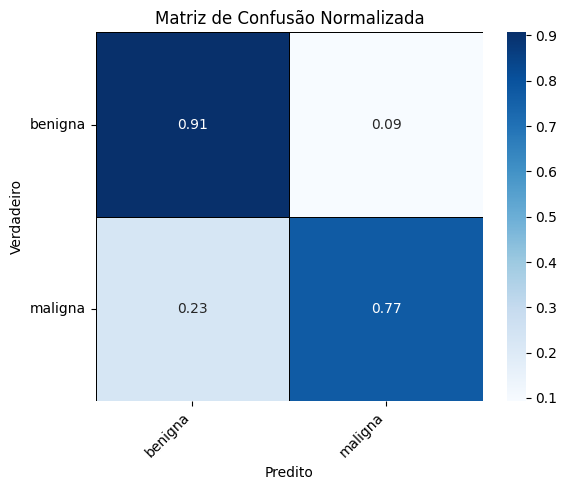

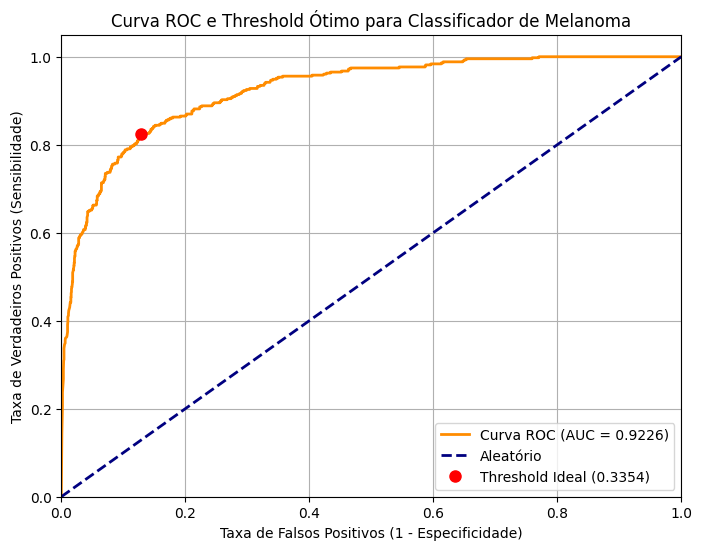

In [ ]:
val_pred_proba, val_pred, val_bal_acc, val_report = predict_and_evaluate(model, val_batches, y_val)
optimal_threshold, roc_auc = plot_roc_curve(y_val, val_pred_proba)

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
Balanced Accuracy: 0.8459723626558814
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      2070
           1       0.57      0.82      0.67       430

    accuracy                           0.86      2500
   macro avg       0.76      0.85      0.79      2500
weighted avg       0.89      0.86      0.87      2500



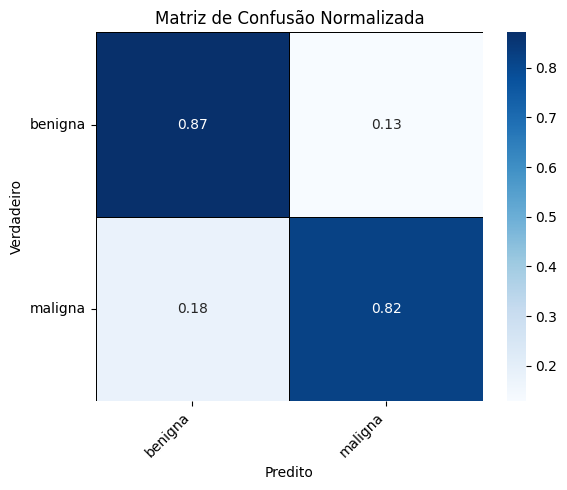

In [ ]:
val_pred_proba, val_pred, val_bal_acc, val_report = predict_and_evaluate(model, val_batches, y_val, optimal_threshold)

In [ ]:

# Diretório das imagens de teste
TEST_DIR = BASE_DIR + '/images/test/'
SAVE_DIR = os.path.join(os.path.dirname(BASE_DIR.rstrip('/')), 'effnetv2b0_models_submissions')

test_file_paths = sorted(glob.glob(os.path.join(TEST_DIR, '*.jpg')))
submission_ids = [f"images/test/{os.path.basename(path)}" for path in test_file_paths]

# Carregamento e pré-processamento de teste
test_path_ds = tf.data.Dataset.from_tensor_slices(test_file_paths)
test_images_ds = test_path_ds.map(load_and_preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
test_batches = test_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Predições em teste
test_proba, test_pred = predict_and_evaluate(model, test_batches, None, optimal_threshold)

# Arquivo de submissão
submission_df = pd.DataFrame({
    'ID': submission_ids,
    'TARGET': test_pred
})

# Salvar o modelo e o arquivo de submissão para avaliar o conjunto de teste
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
submission_filename = f'{timestamp}_effnetv2b0_submission.csv'
model_filename = f'{timestamp}_effnetv2b0_model.keras'

submission_df.to_csv(os.path.join(SAVE_DIR, submission_filename), index=False)
model.save(os.path.join(SAVE_DIR, model_filename))
print("Modelo e Submissão Salvos")

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step
Modelo e Submissão Salvos


## Ensemble de Modelos com K-Fold(EfficientNetV2B0)

In [13]:
# Configurações
N_FOLDS = 5 # Número de folds utilizados
BATCH_SIZE = 32
EPOCHS = 40
IMG_SIZE = (224, 224)
SAVE_DIR = "/content/drive/MyDrive/MDC_data/models_kfold" # Pasta para salvar modelos
os.makedirs(SAVE_DIR, exist_ok=True)


def get_compiled_model():
    base = tf.keras.applications.EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = True

    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(2, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(1e-4),
        metrics=['accuracy']
    )
    return model


In [14]:
train_info = pd.read_csv("/content/drive/MyDrive/MDC_data/train.csv")
X_paths = np.array([os.path.join(BASE_DIR, p) for p in train_info['path']])
y_labels = train_info['target'].values

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_histories = [] # Armazena métricas de cada fold

df_train = pd.read_csv("/content/drive/MyDrive/MDC_data/train.csv")
df_val = pd.read_csv("/content/drive/MyDrive/MDC_data/val.csv")

# Concatenação de conjunto de treinamento e validação para definição de split por fold
full_df = pd.concat([df_train, df_val], ignore_index=True)
X_paths = np.array([os.path.join(BASE_DIR, p) for p in full_df['path']])
y_labels = full_df['target'].values


In [ ]:
print(f"Iniciando treinamento K-Fold ({N_FOLDS} folds)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_paths, y_labels)):
    print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")
    tf.keras.backend.clear_session() # Limpa memória

    # Datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_paths[train_idx], y_labels[train_idx]))
    val_ds = tf.data.Dataset.from_tensor_slices((X_paths[val_idx], y_labels[val_idx]))

    # Pipeline
    train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # Treinamento
    model = get_compiled_model()
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(f"{SAVE_DIR}/model_fold_{fold+1}.keras", save_best_only=True)
    ]

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    fold_histories.append(history.history)

print("\nK-Fold concluído. Métricas armazenadas em 'fold_histories'.")

Iniciando treinamento K-Fold (5 folds)...

--- Fold 1/5 ---
Epoch 1/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 1025s 1s/step - accuracy: 0.6384 - loss: 0.5844 - val_accuracy: 0.7876 - val_loss: 0.4552
Epoch 2/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - accuracy: 0.7688 - loss: 0.4583 - val_accuracy: 0.8042 - val_loss: 0.3972
Epoch 3/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - accuracy: 0.7920 - loss: 0.4210 - val_accuracy: 0.8113 - val_loss: 0.4016
Epoch 4/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 39s 66ms/step - accuracy: 0.8176 - loss: 0.3837 - val_accuracy: 0.8577 - val_loss: 0.3359
Epoch 5/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - accuracy: 0.8213 - loss: 0.3599 - val_accuracy: 0.8305 - val_loss: 0.3709
Epoch 6/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 38s 64ms/step - accuracy: 0.8331 - loss: 0.3324 - val_accuracy: 0.8183 - val_loss: 0.3871
Epoch 7/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - accuracy: 0.8479 - loss: 0.3148 - val_accuracy: 0.8334 - val_loss: 0.3662
Epoch 8/40
571/571 ━━━━━━━━━━━

In [15]:
# Carregamento do dataset novamente para gerar previsões
print(f"Dataset Total Reconstruído: {len(full_df)} imagens (Treino + Val Originais)")

X_paths = np.array([os.path.join(BASE_DIR, p) for p in full_df['path']])
y_labels = full_df['target'].values

oof_preds_global = np.zeros(len(X_paths))
oof_targets_global = np.zeros(len(X_paths))

# Configuração do K-Fold (mesmo SEED do treinamento)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_metrics_summary = []

Dataset Total Reconstruído: 22831 imagens (Treino + Val Originais)


In [19]:
import keras


==================== AVALIANDO FOLD 1/5 ====================
Threshold Ideal: 0.3637
Balanced Accuracy: 0.80913
Matriz de Confusão:
        Pred 0  Pred 1
Real 0    3000     757
Real 1     146     664


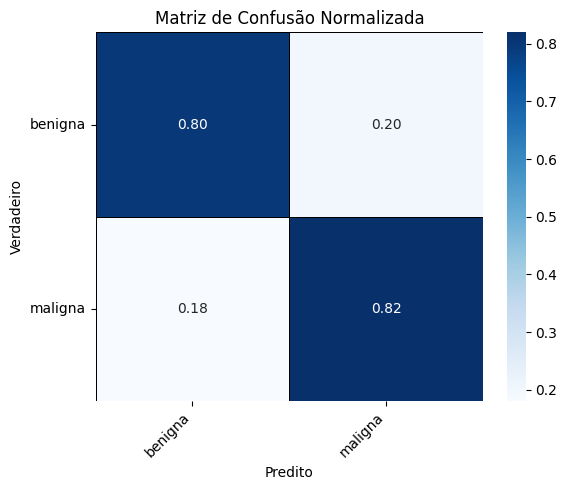


==================== AVALIANDO FOLD 2/5 ====================
Threshold Ideal: 0.2025
Balanced Accuracy: 0.82369
Matriz de Confusão:
        Pred 0  Pred 1
Real 0    3039     717
Real 1     131     679


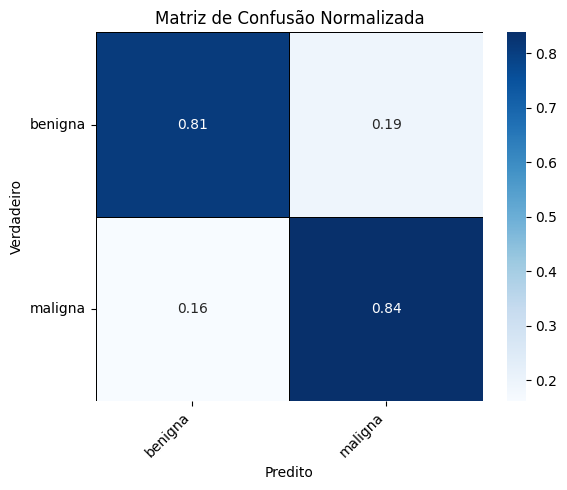


==================== AVALIANDO FOLD 3/5 ====================
Threshold Ideal: 0.4165
Balanced Accuracy: 0.82281
Matriz de Confusão:
        Pred 0  Pred 1
Real 0    3204     552
Real 1     168     642


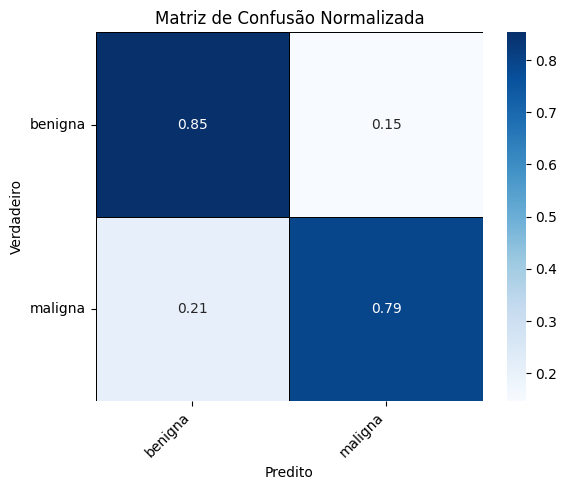


==================== AVALIANDO FOLD 4/5 ====================
Threshold Ideal: 0.3186
Balanced Accuracy: 0.83951
Matriz de Confusão:
        Pred 0  Pred 1
Real 0    3181     575
Real 1     136     674


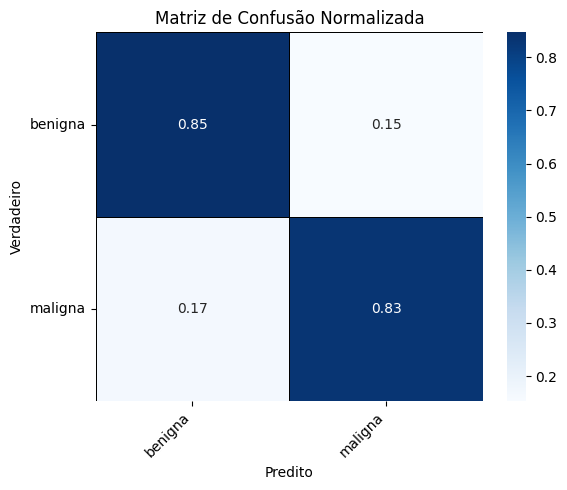


==================== AVALIANDO FOLD 5/5 ====================
Threshold Ideal: 0.3451
Balanced Accuracy: 0.82871
Matriz de Confusão:
        Pred 0  Pred 1
Real 0    3239     517
Real 1     166     644


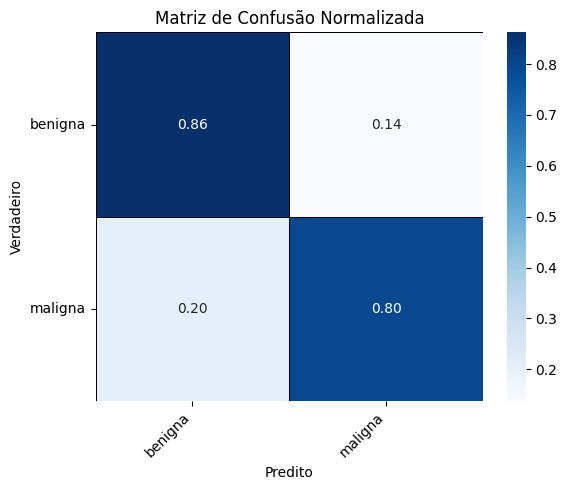

In [24]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X_paths, y_labels)):
    fold_num = fold + 1
    print(f"\n{'='*20} AVALIANDO FOLD {fold_num}/{N_FOLDS} {'='*20}")

    # Carregar o modelo do fold
    model_path = os.path.join(SAVE_DIR, f"model_fold_{fold_num}.keras")
    if not os.path.exists(model_path):
        print(f"Modelo não encontrado: {model_path}")
        continue

    model = keras.models.load_model(model_path)

    X_val_fold = X_paths[val_idx]
    y_val_fold = y_labels[val_idx]

    val_ds = tf.data.Dataset.from_tensor_slices((X_val_fold, y_val_fold))
    val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # 3. Predição
    val_probs = model.predict(val_ds, verbose=0)
    prob_maligno = val_probs[:, 1]

    # Armazenar no array Global (OOF)
    oof_preds_global[val_idx] = prob_maligno
    oof_targets_global[val_idx] = y_val_fold

    # 4. Métricas LOCAIS do Fold (Threshold Otimizado Local)
    fpr, tpr, thresholds = roc_curve(y_val_fold, prob_maligno)
    best_thresh_fold = thresholds[np.argmax(tpr - fpr)]

    preds_fold = np.where(prob_maligno > best_thresh_fold, 1, 0)
    bal_acc = balanced_accuracy_score(y_val_fold, preds_fold)
    cm = confusion_matrix(y_val_fold, preds_fold)

    # Exibir Métricas do Fold
    print(f"Threshold Ideal: {best_thresh_fold:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.5f}")
    print("Matriz de Confusão:")
    print(pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))

    # Gerar matriz de confusão para o fold
    plot_confusion_matrix(y_val_fold, preds_fold, ['benigna', 'maligna'], 2)

    fold_metrics_summary.append({
        'Fold': fold_num,
        'Threshold': best_thresh_fold,
        'Bal_Acc': bal_acc,
        'TP': cm[1,1], 'TN': cm[0,0], 'FP': cm[0,1], 'FN': cm[1,0]
    })

    tf.keras.backend.clear_session()


==================== ANÁLISE CONSOLIDADA ====================

--- PERFORMANCE GLOBAL DO ENSEMBLE (CROSS-VALIDATION) ---
Threshold Otimizado Global: 0.34006
Balanced Accuracy Global: 0.82362

Matriz de Confusão Global (OOF):
              Pred Benigno  Pred Maligno
Real Benigno         15680          3101
Real Maligno           760          3290


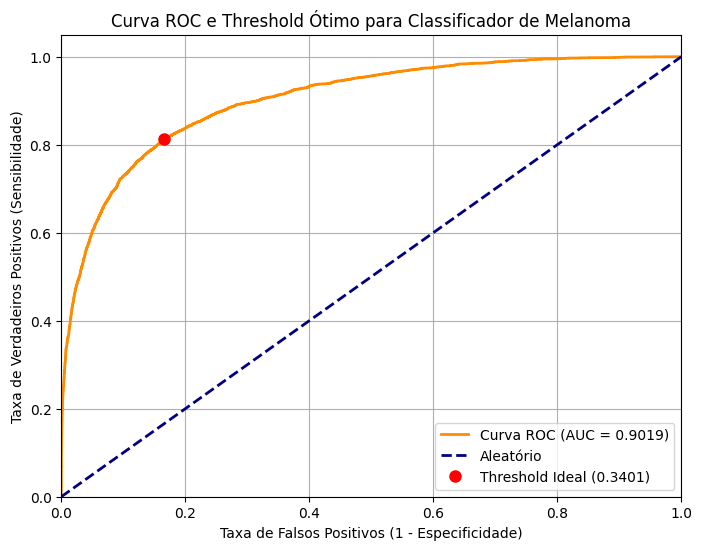

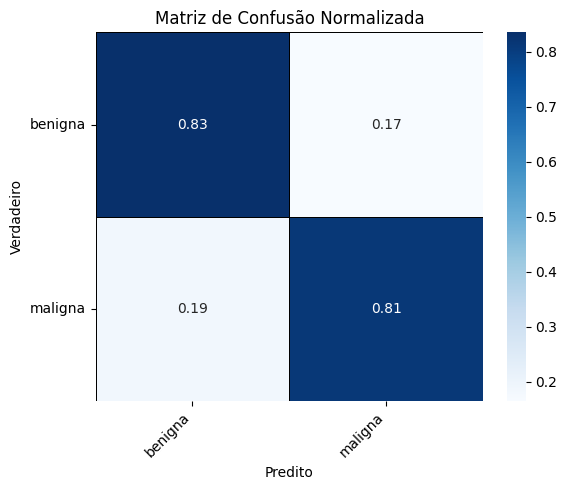

In [32]:
print(f"\n{'='*20} ANÁLISE CONSOLIDADA {'='*20}")

# 2. Cálculo do Threshold Global (Usando todas as previsões OOF juntas)
fpr, tpr, thresholds = roc_curve(oof_targets_global, oof_preds_global)
optimal_threshold_global = thresholds[np.argmax(tpr - fpr)]

# 3. Métricas Globais Finais
global_preds = np.where(oof_preds_global > optimal_threshold_global, 1, 0)
global_bal_acc = balanced_accuracy_score(oof_targets_global, global_preds)
global_cm = confusion_matrix(oof_targets_global, global_preds)

print("\n--- PERFORMANCE GLOBAL DO ENSEMBLE (CROSS-VALIDATION) ---")
print(f"Threshold Otimizado Global: {optimal_threshold_global:.5f}")
print(f"Balanced Accuracy Global: {global_bal_acc:.5f}")
print("\nMatriz de Confusão Global (OOF):")
print(pd.DataFrame(global_cm, index=['Real Benigno', 'Real Maligno'], columns=['Pred Benigno', 'Pred Maligno']))

# Plot the global ROC curve
optimal_threshold_global, roc_auc_global = plot_roc_curve(oof_targets_global, np.stack([1 - oof_preds_global, oof_preds_global], axis=1))

# Plot the global confusion matrix
plot_confusion_matrix(oof_targets_global, global_preds, ['benigna', 'maligna'], 2)

In [26]:
print(f"Usando Threshold Otimizado Global: {optimal_threshold_global:.5f}")

# Listar arquivos de teste (Ordenado é importante para manter consistência)
test_file_paths = sorted(glob.glob(os.path.join(BASE_DIR, 'images/test/*.jpg')))

# Pipeline de Teste (Simples, apenas Resize e Rescale)
test_ds = tf.data.Dataset.from_tensor_slices(test_file_paths)
test_ds = test_ds.map(load_and_preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
test_batches = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Total de imagens de teste: {len(test_file_paths)}")

Usando Threshold Otimizado Global: 0.34006
Total de imagens de teste: 2500


In [ ]:
print(f"\n--- Iniciando Predição Ensemble ({N_FOLDS} Folds) ---")
ensemble_probs_sum = np.zeros((len(test_file_paths), 2))

for fold in range(1, N_FOLDS + 1):
    model_path = os.path.join(SAVE_DIR, f"model_fold_{fold}.keras")
    print(f"-> Carregando e prevendo: {model_path} ...", end=" ")

    if not os.path.exists(model_path):
        print("Arquivo não encontrado!")
        continue

    model = keras.models.load_model(model_path)

    probs = model.predict(test_batches, verbose=0)

    ensemble_probs_sum += probs

    print("Concluído.")

    tf.keras.backend.clear_session()


--- Iniciando Predição Ensemble (5 Folds) ---
-> Carregando e prevendo: /content/drive/MyDrive/MDC_data/models_kfold/model_fold_1.keras ... Concluído.
-> Carregando e prevendo: /content/drive/MyDrive/MDC_data/models_kfold/model_fold_2.keras ... Concluído.
-> Carregando e prevendo: /content/drive/MyDrive/MDC_data/models_kfold/model_fold_3.keras ... Concluído.
-> Carregando e prevendo: /content/drive/MyDrive/MDC_data/models_kfold/model_fold_4.keras ... Concluído.
-> Carregando e prevendo: /content/drive/MyDrive/MDC_data/models_kfold/model_fold_5.keras ... Concluído.


In [ ]:
print("\n--- Processando Resultados Finais ---")

avg_probs = ensemble_probs_sum / N_FOLDS
prob_maligno_final = avg_probs[:, 1]
final_preds = np.where(prob_maligno_final > optimal_threshold_global, 1, 0)

# Montar o DataFrame de Submissão
submission_ids = [f"images/test/{os.path.basename(p)}" for p in test_file_paths]

submission_df = pd.DataFrame({
    'ID': submission_ids,
    'TARGET': final_preds
})

# Salvar Arquivo
sub_filename = os.path.join(SAVE_DIR, f"submission_ensemble_{N_FOLDS}folds_th{optimal_threshold_global:.4f}.csv")
submission_df.to_csv(sub_filename, index=False)

print(f"Submissão salva com sucesso em:")
print(f"   -> {sub_filename}")



--- Processando Resultados Finais ---
Submissão salva com sucesso em:
   -> /content/drive/MyDrive/MDC_data/models_kfold/submission_ensemble_5folds_th0.3401.csv

Primeiras 5 linhas:


In [27]:
def predict_with_tta_geometry_test(model, dataset, steps):
    """
    Realiza inferência com 4 visualizações (Original + Flips + Rotação)
    e retorna a média das probabilidades.
    """
    final_probs = []

    for images in dataset.take(steps):
        batch_sum = np.zeros((images.shape[0], 2)) # Acumulador (Batch Size, 2 Classes)

        # Visualização Original
        batch_sum += model.predict(images, verbose=0)

        # Flip Horizontal (Espelhamento)
        batch_sum += model.predict(tf.image.flip_left_right(images), verbose=0)

        # Flip Vertical (Cabeça para baixo)
        batch_sum += model.predict(tf.image.flip_up_down(images), verbose=0)

        # Rotação de 90 graus
        batch_sum += model.predict(tf.image.rot90(images, k=1), verbose=0)

        # Média das 4 visualizações para este batch
        batch_avg = batch_sum / 4.0
        final_probs.extend(batch_avg)

    return np.array(final_probs)

Teste da Técnica de TTA(Test-Time Augmentation)

In [28]:
# Utilizando técnica de TTA, aumentation do conjunto de teste para gerar previsões do conjunto de teste aumentado e definir uma predição final com base na média
print(f"\n--- Iniciando Predição Ensemble COM TTA ({N_FOLDS} Folds) ---")

ensemble_probs_sum = np.zeros((len(test_file_paths), 2))
steps = len(test_batches)

for fold in range(1, N_FOLDS + 1):
    model_path = os.path.join(SAVE_DIR, f"model_fold_{fold}.keras")
    print(f"-> Carregando e prevendo (TTA): {model_path} ...", end=" ")

    if not os.path.exists(model_path):
        print("Arquivo não encontrado!")
        continue

    model = keras.models.load_model(model_path)
    probs = predict_with_tta_geometry_test(model, test_batches, steps)
    ensemble_probs_sum += probs

    print("Concluído.")

    tf.keras.backend.clear_session()


--- Iniciando Predição Ensemble COM TTA (5 Folds) ---
-> Carregando e prevendo (TTA): /content/drive/MyDrive/MDC_data/models_kfold/model_fold_1.keras ... Concluído.
-> Carregando e prevendo (TTA): /content/drive/MyDrive/MDC_data/models_kfold/model_fold_2.keras ... Concluído.
-> Carregando e prevendo (TTA): /content/drive/MyDrive/MDC_data/models_kfold/model_fold_3.keras ... Concluído.
-> Carregando e prevendo (TTA): /content/drive/MyDrive/MDC_data/models_kfold/model_fold_4.keras ... Concluído.
-> Carregando e prevendo (TTA): /content/drive/MyDrive/MDC_data/models_kfold/model_fold_5.keras ... Concluído.


In [29]:
print("\n--- Processando Resultados Finais (TTA) ---")

avg_probs = ensemble_probs_sum / N_FOLDS
prob_maligno_final = avg_probs[:, 1]

print(f"Aplicando Threshold Global: {optimal_threshold_global:.4f}")
final_preds = np.where(prob_maligno_final > optimal_threshold_global, 1, 0)
submission_ids = [f"images/test/{os.path.basename(p)}" for p in test_file_paths]

# Montar o DataFrame de Submissão
submission_df = pd.DataFrame({
    'ID': submission_ids,
    'TARGET': final_preds
})

# Salvar Arquivo
sub_filename = os.path.join(SAVE_DIR, f"submission_ensemble_{N_FOLDS}folds_TTA_th{optimal_threshold_global:.4f}.csv")
submission_df.to_csv(sub_filename, index=False)

print(f"Submissão TTA salva com sucesso em:")
print(f"   -> {sub_filename}")


--- Processando Resultados Finais (TTA) ---
Aplicando Threshold Global: 0.3401
Submissão TTA salva com sucesso em:
   -> /content/drive/MyDrive/MDC_data/models_kfold/submission_ensemble_5folds_TTA_th0.3401.csv


## Explicabilidade do Modelo

In [33]:
def unwrap_model(model, last_conv_layer_name, base_model_name):
    n_model = model.get_layer(base_model_name)
    n_model_conv_out = n_model.get_layer(last_conv_layer_name).output
    inp = n_model.input

    # Reconstroi o classificador (GAP, Dropout, Dense)
    other_layers = model.layers[1:]
    curr_out = n_model_conv_out
    for layer in other_layers:
        curr_out = layer(curr_out)

    return tf.keras.models.Model(inp, [n_model_conv_out, curr_out])

In [34]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None, base_model_name=None):
    if base_model_name is None:
        grad_model = keras.models.Model(
            model.inputs, [model.get_layer(last_conv_layer_name).output, model.layers[-1].output]
        )
    else:
        grad_model = unwrap_model(model, last_conv_layer_name, base_model_name)

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [40]:
def show_ensemble_heatmap(img, heatmap, alpha=0.5):
    heatmap = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    plt.figure(figsize=(10, 5))
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

In [66]:
def get_superimposed_img(img, heatmap, alpha=0.5):
    """Função auxiliar para gerar a sobreposição RGB"""
    heatmap_uint8 = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]

    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    return keras.utils.array_to_img(superimposed_img)

def explain_ensemble_image(img_path, model_dir, n_folds=5):
    # Carregamento da imagem
    img_tensor = load_and_preprocess(img_path, None)[0]
    img_batch = np.expand_dims(img_tensor, axis=0)

    raw_img = keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_np = keras.utils.img_to_array(raw_img)

    heatmaps = []

    # Geração de um heatmap por fold
    for fold in range(1, n_folds + 1):
        m_path = os.path.join(model_dir, f"model_fold_{fold}.keras")
        model = keras.models.load_model(m_path)

        hm = make_gradcam_heatmap(
            img_batch,
            model,
            last_conv_layer_name='top_activation',
            base_model_name=model.layers[0].name,
            pred_index=1
        )
        heatmaps.append(hm)
        tf.keras.backend.clear_session()

    # Obtenção do heatmap de Ensemble - Médio
    ensemble_heatmap = np.mean(heatmaps, axis=0)

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    plt.suptitle("Análise de Explicabilidade(Grad-CAM) - Folds e Ensemble", fontweight='bold',fontsize=24)
    axes = axes.flatten()
    # Original
    axes[0].imshow(raw_img)
    axes[0].set_title("Original", fontsize=20, fontweight='bold')
    axes[0].axis('off')

    # 1 plot por Fold
    for i, hm in enumerate(heatmaps):
        # Sobrepor heatmap na imagem para o plot
        superimposed = get_superimposed_img(img_np, hm)
        axes[i+1].imshow(superimposed)
        axes[i+1].set_title(f"Fold {i+1}", fontsize=18)
        axes[i+1].axis('off')

    # Ensemble final
    ensemble_img = get_superimposed_img(img_np, ensemble_heatmap)
    axes[6].imshow(ensemble_img)
    axes[6].set_title("ENSEMBLE (Média)", fontsize=20, fontweight='bold', color='red')
    axes[6].axis('off')
    axes[7].axis('off')

    plt.tight_layout()

In [67]:
# Índices de Falsos Negativos
fn_indices = np.where((oof_targets_global == 1) & (global_preds == 0))[0]

# Índices de Verdadeiros Positivos
tp_indices = np.where((oof_targets_global == 1) & (global_preds == 1))[0]

print(f"Falsos Negativos encontrados: {len(fn_indices)}")
print(f"Verdadeiros Positivos encontrados: {len(tp_indices)}")

Falsos Negativos encontrados: 760
Verdadeiros Positivos encontrados: 3290



Explicando Falso Negativo - Índice: 10


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


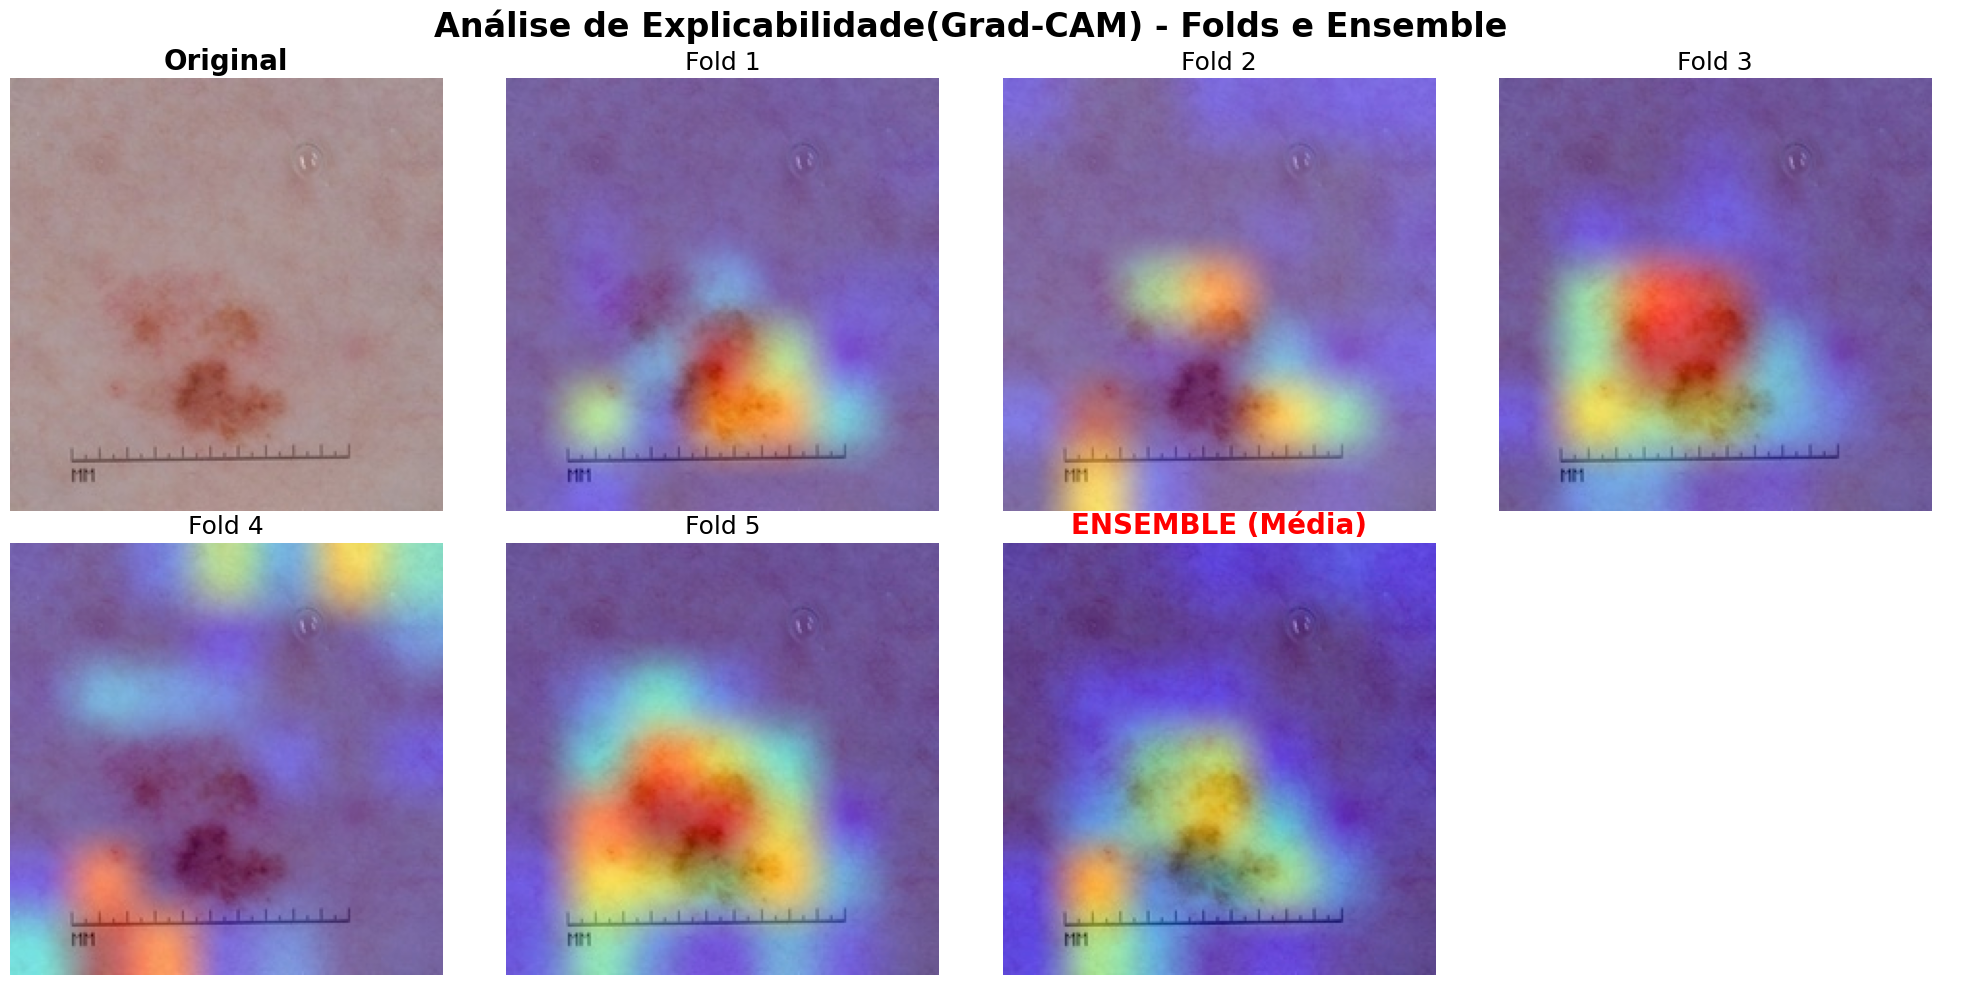

In [68]:
if len(fn_indices) > 0:
    idx = fn_indices[0]
    print(f"\nExplicando Falso Negativo - Índice: {idx}")
    explain_ensemble_image(X_paths[idx], SAVE_DIR, n_folds=N_FOLDS)


Explicando Verdade Positivo - Índice: 1


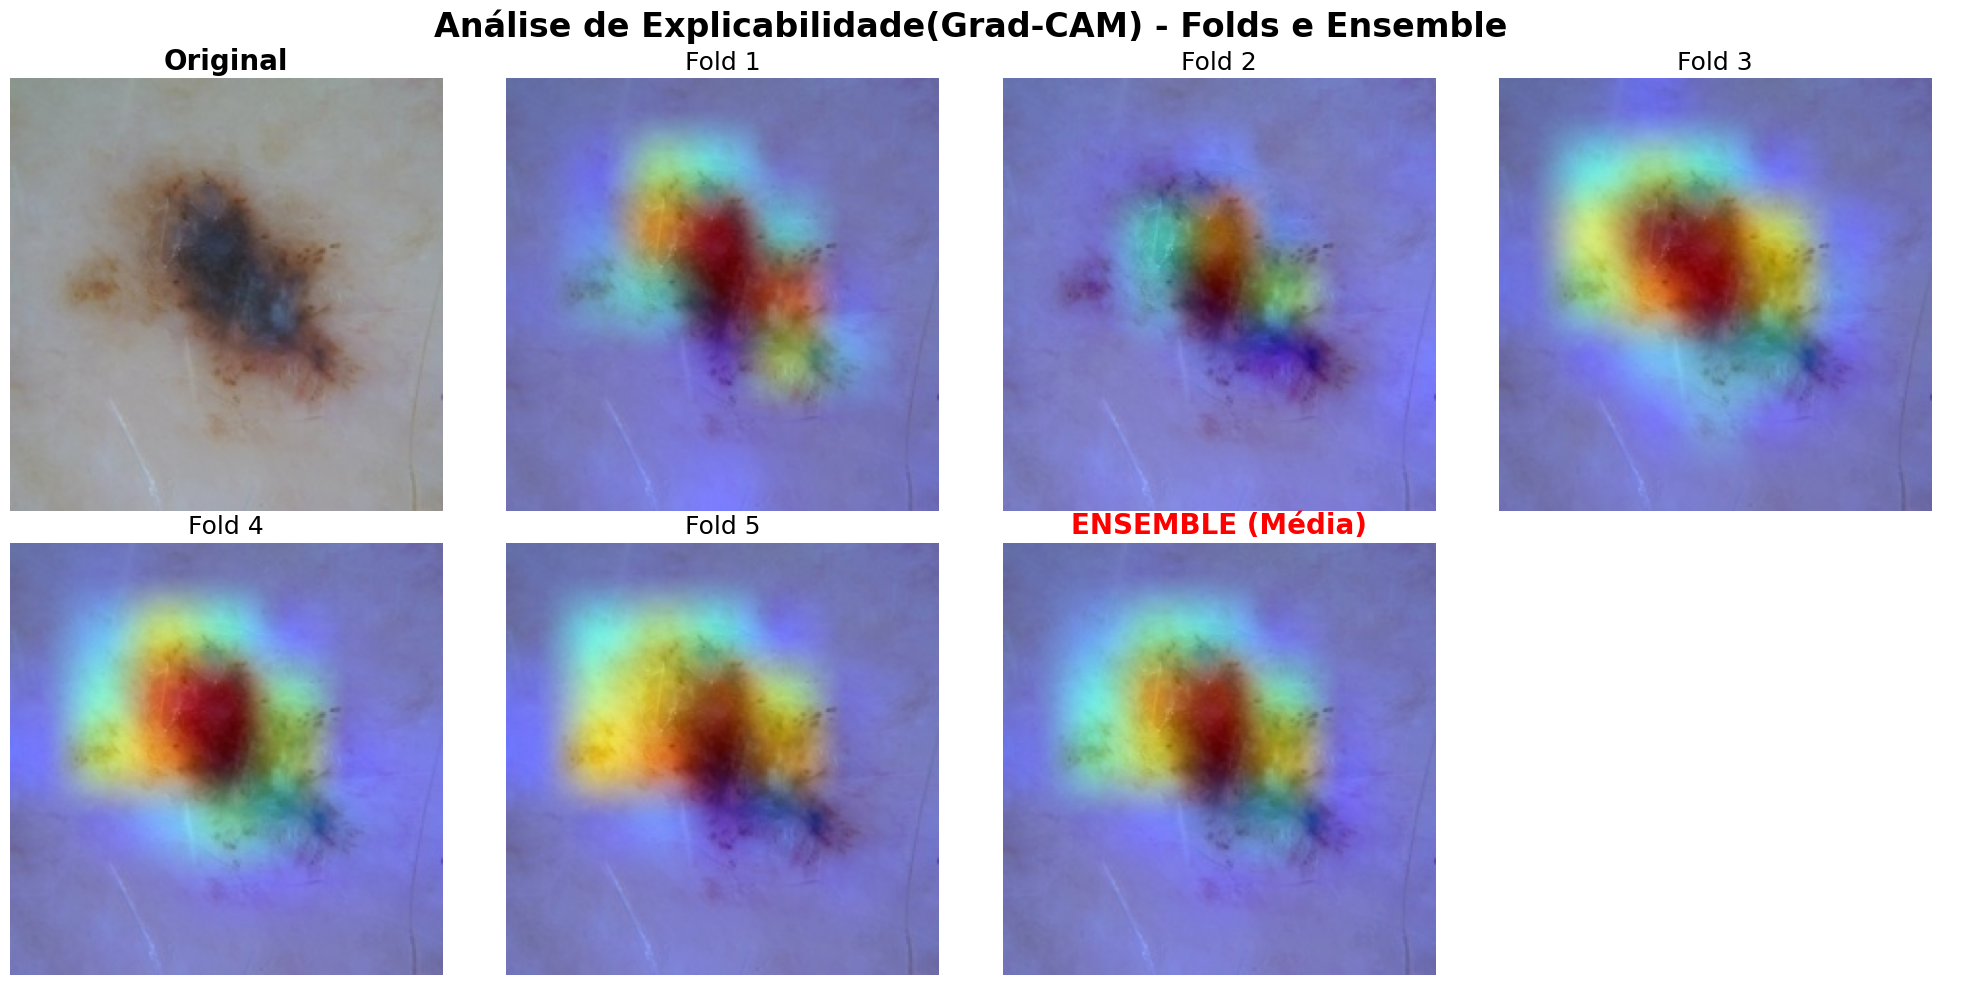

In [69]:
if len(tp_indices) > 0:
    idx = tp_indices[0]
    print(f"\nExplicando Verdade Positivo - Índice: {idx}")
    explain_ensemble_image(X_paths[idx], SAVE_DIR, n_folds=N_FOLDS)


Explicando Falso Negativo - Índice: 24


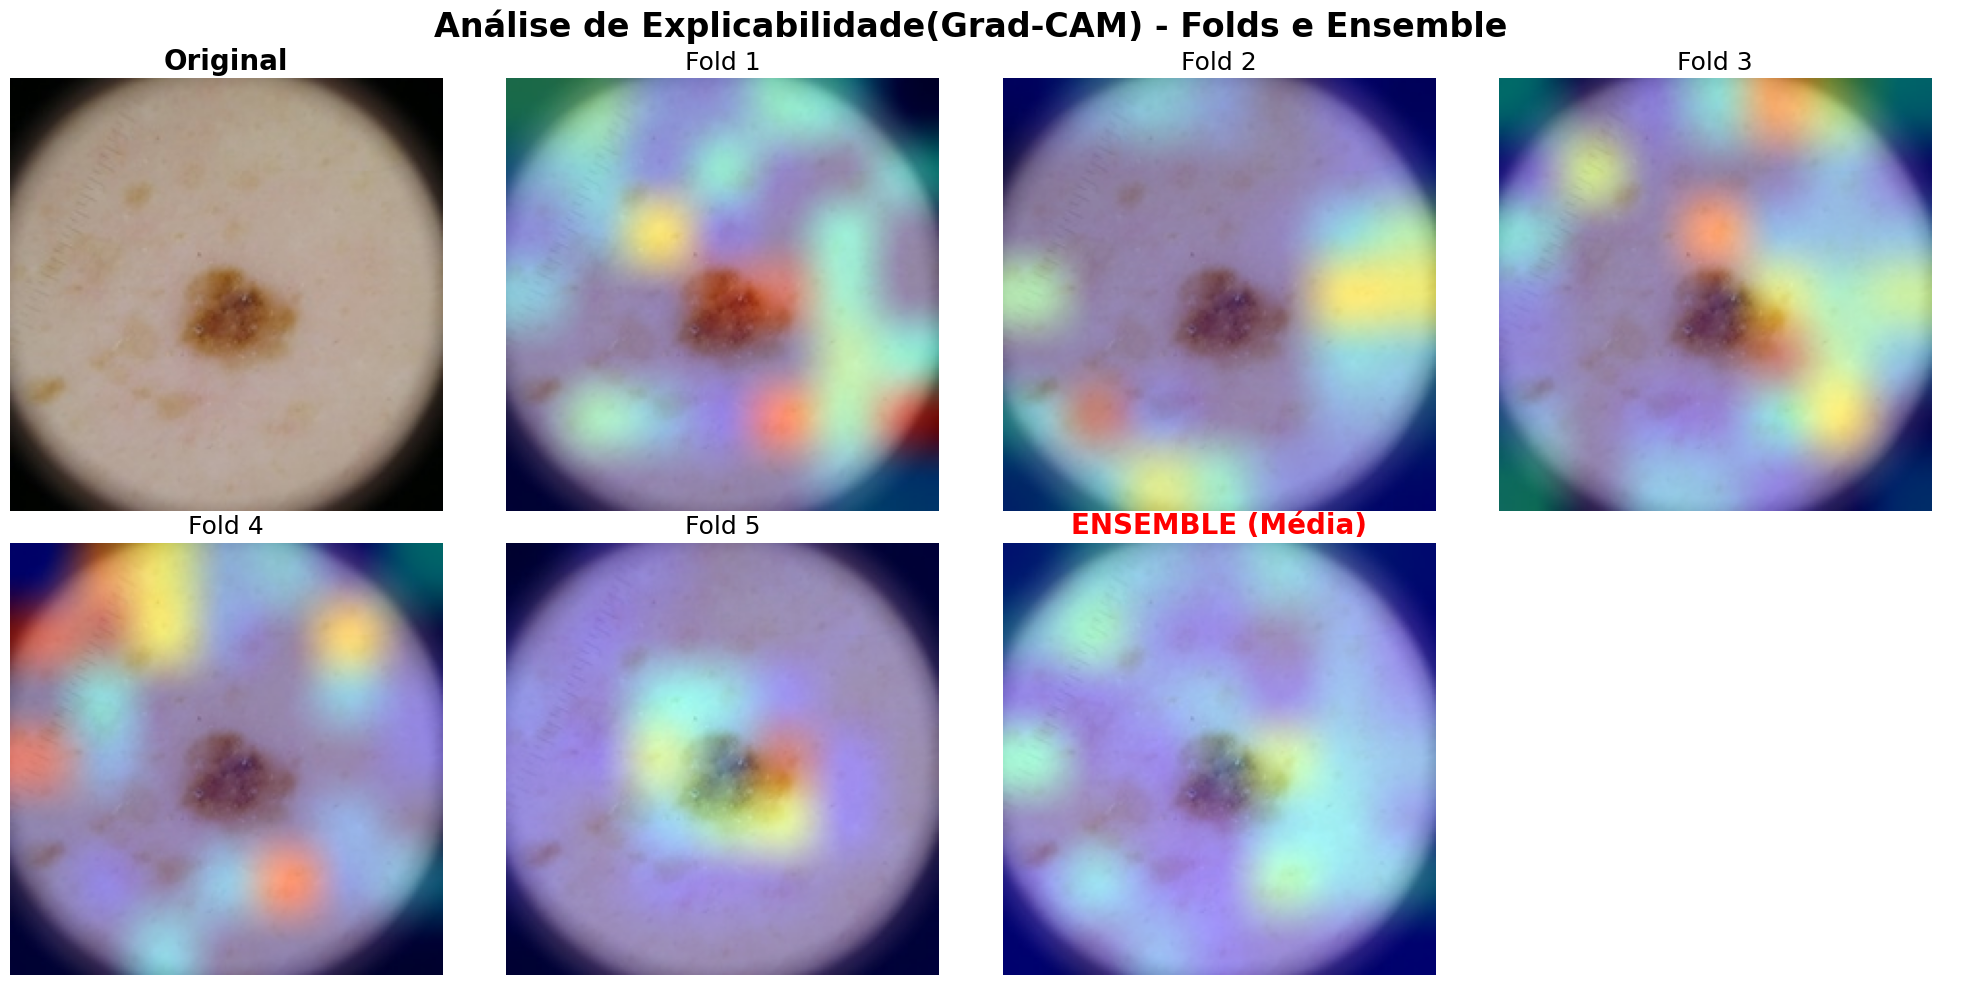

In [72]:
if len(fn_indices) > 0:
    idx = fn_indices[1]
    print(f"\nExplicando Falso Negativo - Índice: {idx}")
    explain_ensemble_image(X_paths[idx], SAVE_DIR, n_folds=N_FOLDS)


Explicando Verdade Positivo - Índice: 6


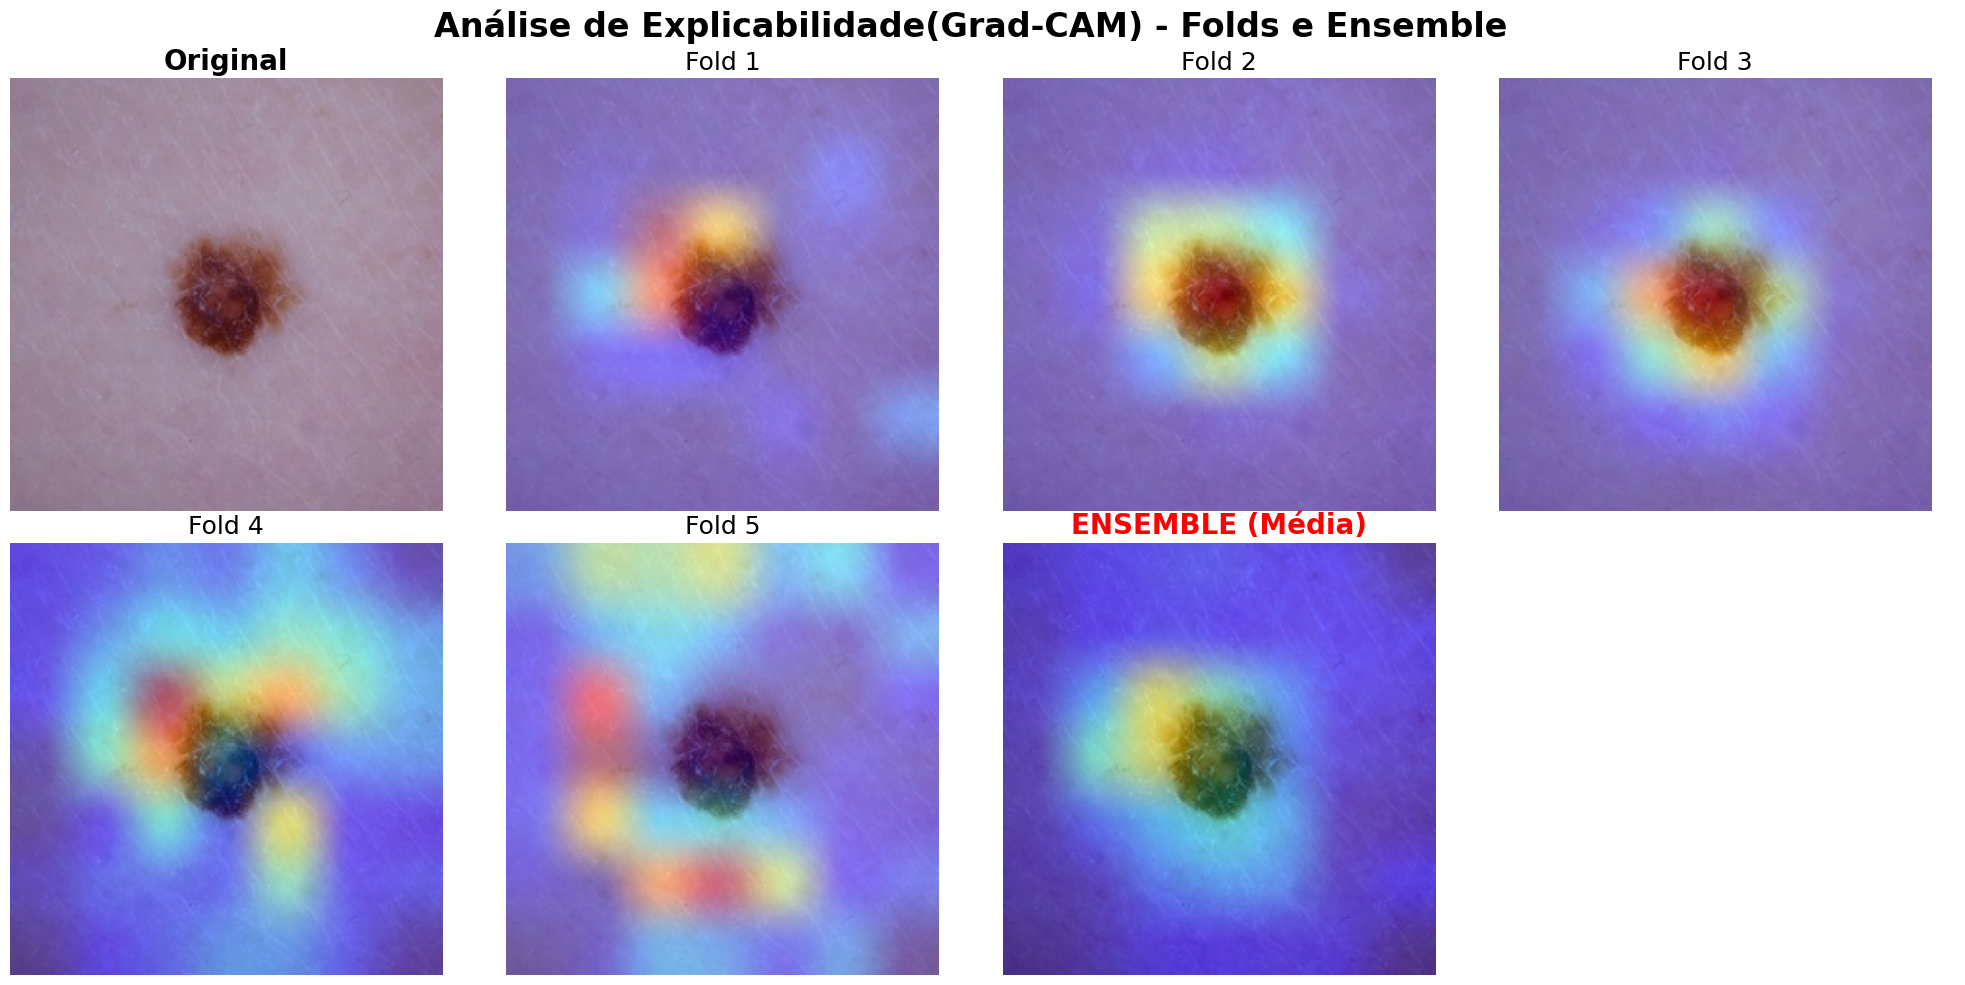

In [71]:
if len(tp_indices) > 0:
    idx = tp_indices[1]
    print(f"\nExplicando Verdade Positivo - Índice: {idx}")
    explain_ensemble_image(X_paths[idx], SAVE_DIR, n_folds=N_FOLDS)